In [48]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv("car_acceptability.csv")
df.head()

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [50]:
le = LabelEncoder()

df["buying price"] = le.fit_transform(df["buying price"])
df["maintenance cost"] = le.fit_transform(df["maintenance cost"])
df["lug_boot"] = le.fit_transform(df["lug_boot"])
df["safety"] = le.fit_transform(df["safety"])
df["evaluation"] = le.fit_transform(df["evaluation"])


In [51]:
#df

In [52]:
x = df.drop("evaluation", axis=1)
y = df["evaluation"]

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [54]:
svm_model = SVC(kernel="linear")
svm_model.fit(X_train, Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [55]:
Y_pred = svm_model.predict(X_test)

In [56]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.7138728323699421


In [57]:
cm = confusion_matrix(Y_test, Y_pred)

In [58]:
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[ 12   0  65   0]
 [  0   0  15   0]
 [  2   0 235   0]
 [ 12   0   5   0]]


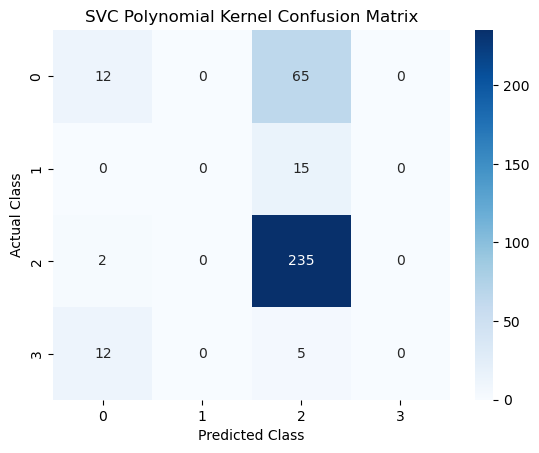

In [59]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("SVC Polynomial Kernel Confusion Matrix")
plt.show()

In [60]:
svm_model = SVC(kernel="poly")
svm_model.fit(X_train, Y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [61]:
Y_pred = svm_model.predict(X_test)

In [62]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
cm = confusion_matrix(Y_test, Y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.838150289017341

Confusion Matrix:
 [[ 50   0  26   1]
 [  6   4   2   3]
 [ 13   0 224   0]
 [  4   0   1  12]]
